In [11]:
# Import Libraries and Modules
import os
import time
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # Hide tensorflow warnings

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Input, LSTM

# Allow TensorFlow to use all available CPU cores 
CPU_CORES = os.cpu_count()
tf.config.threading.set_intra_op_parallelism_threads(CPU_CORES)
tf.config.threading.set_inter_op_parallelism_threads(CPU_CORES)

In [5]:
# Create model directories
os.makedirs("models/rf/train", exist_ok=True)
os.makedirs("models/dnn/train", exist_ok=True)
os.makedirs("models/lstm/train", exist_ok=True)

In [6]:
# Target column used for multiclass classification
TARGET_COL = "Attack Group"

# Columns excluded from feature set during training
DROP_COLS = ['Binary Label', 'Attack Group', 'Label', "Dataset"]

In [7]:
# Global Functions

def load_raw_data(path):
    """ Loads CSV dataset and reduces memory usage """

    print("Loading data...")
    df = pd.read_csv(path)

    return reduce_mem_usage(df)

def reduce_mem_usage(df):
    """ Downcasts numeric columns to reduce memory usage """

    # Iterate through all dataframe columns
    for col in df.columns:

        # Convert float64 to float32
        if df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')

        # Convert int64 to int32
        elif df[col].dtype == 'int64':
            df[col] = df[col].astype('int32')
    
    return df

def select_features(df, FEATURES=None):
    """ Splits dataset into features (X) and target label (Y) """

    # Selects features if provided
    if FEATURES is not None:
        X = df[FEATURES]

    # Otherwise use all columns except excluded columns 
    else:
        X = df.drop(columns=DROP_COLS, errors="ignore")
    
    # Extract target labels
    Y = df[TARGET_COL]
    
    return X, Y

def encode_labels(Y):
    """ Encodes target label into numeric values """

    print("Encoding Labels...")

    # Initialise label encoder
    encoder = LabelEncoder()

    # Transform labels into numeric representations
    Y = encoder.fit_transform(Y)

    return Y, encoder

def scale_features(X, method="standard"):
    """ Applies feature scaling to input features """

    print("Applying scaler...")

    # Standardise using standard scaler
    if method == "standard":
        scaler = StandardScaler()

    # Standardise using minmax scaler
    elif method == "minmax":
        scaler = MinMaxScaler()

    # Fit and transform features    
    X = scaler.fit_transform(X)

    return X, scaler

def apply_pca(X, n_components):
    """ Applies PCA for dimensionality reduction """

    print("Appling PCA...")

    # Initialise PCA model
    pca = PCA(n_components=n_components)

    # Transform features into principal components
    X = pca.fit_transform(X)

    return X, pca

In [ ]:
# Confusion Matrix Plot (Binary Classification)
def plot_cm(cm, ax, title, cmap):
    """ Plots a labeled confusion matrix with TN/FP/FN/TP annotations """

    # Label each cell with confusion matrix meaning
    group_names = np.array([["TN", "FP"],
                            ["FN", "TP"]])

    # Format raw counts with commas
    labels = np.array([[f"{cm[0,0]:,}", f"{cm[0,1]:,}"],
                       [f"{cm[1,0]:,}", f"{cm[1,1]:,}"]])

    # Combine label type + value in each cell
    annot = np.array([[f"{group_names[0,0]}\n{labels[0,0]}",
                       f"{group_names[0,1]}\n{labels[0,1]}"],
                      [f"{group_names[1,0]}\n{labels[1,0]}",
                       f"{group_names[1,1]}\n{labels[1,1]}"]])

    # Heatmap visualisation
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap=cmap,
        cbar=False,
        xticklabels=["Benign", "Attack"],
        yticklabels=["Benign", "Attack"],
        ax=ax,
        annot_kws={"fontsize": 14}
    )

    # Axis labels and title
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

# Full Model Evaluation Figure (CM + Report)
def plot_model_evaluation_figure(cm,class_labels,precision,recall,f1_score,figure_title="Model Evaluation",figsize=(20, 8)):
    """ Full model evaluation figure (CM + Report) """

    # Build classification report table
    report = pd.DataFrame({
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1_score
    }, index=class_labels)

    # Convert confusion matrix to numpy array
    cm = np.array(cm)

    # Convert counts into percentages
    cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    # Build annotation with counts + percentages
    annot = np.empty_like(cm, dtype=object)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]:,}\n({cm_percent[i, j]:.2f}%)"

    # Create side-by-side plots
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # Confusion Matrix plot
    sns.heatmap(
        cm_percent,
        ax=axes[0],
        cmap="Blues",
        xticklabels=class_labels,
        yticklabels=class_labels,
        cbar=False,
        annot=annot,
        fmt=""
    )

    axes[0].set_title("Confusion Matrix", fontsize=12)
    axes[0].set_xlabel("Predicted Class")
    axes[0].set_ylabel("True Class")
    axes[0].tick_params(axis='x', rotation=45)

    # Classification Report
    sns.heatmap(
        report,
        ax=axes[1],
        annot=True,
        fmt=".4f",
        cmap="Blues",
        cbar=False 
    )

    axes[1].set_title("Classification Report", fontsize=12)
    axes[1].set_xlabel("Metrics")
    axes[1].set_ylabel("Classes")
    axes[1].tick_params(axis='x', rotation=0)

    plt.suptitle(figure_title, fontsize=14)

    plt.subplots_adjust(wspace=0.15)
    plt.show()

def plot_accuracy_comparison(models, binary_acc, multiclass_acc):
    """
    Plots comparison of binary vs multiclass accuracy across different models
    """

    x = np.arange(len(models))
    width = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))

    # Binary accuracy bars
    bars_bin = ax.bar(
        x - width/2,
        binary_acc,
        width,
        color='blue',
        label="Binary Accuracy"
    )

    # Multiclass accuracy bars
    bars_multi = ax.bar(
        x + width/2,
        multiclass_acc,
        width,
        color='lightblue',
        label="Multi-Class Accuracy"
    )

    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Model")
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.set_ylim(0.996, 0.9975)

    # Annotate binary accuracy values
    for i, bar in enumerate(bars_bin):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{binary_acc[i]:.6f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

    # Annotate multiclass accuracy values
    for i, bar in enumerate(bars_multi):
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height(),
            f"{multiclass_acc[i]:.6f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

    # Title and legend
    plt.title("Binary vs Multi-Class Detection Accuracy Comparison")
    ax.legend()

    plt.tight_layout()
    plt.show()

90% variance retained with 23 components
95% variance retained with 28 components
99% variance retained with 36 components


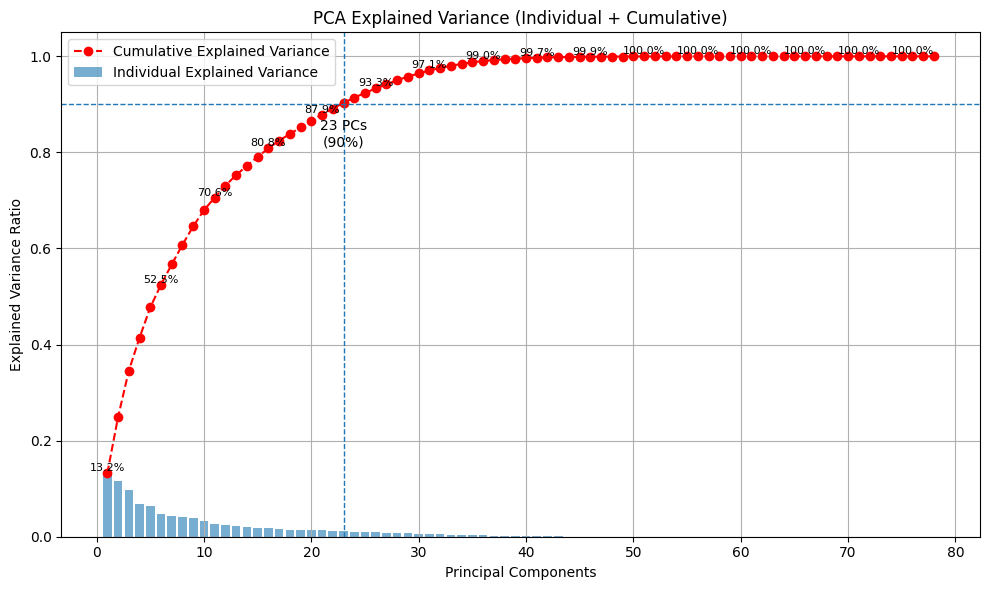

In [8]:
# PCA explained variance analysis

# Training dataset path
DATA = "data/cleaned/partitioned/balanced_train.csv"

# Load and optimise dataset memory usage
data_train = pd.read_csv(DATA)
data_train = reduce_mem_usage(data_train)

# Extract features
X_train = data_train.drop(columns=DROP_COLS, errors="ignore")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

# Initialise PCA
pca = PCA()
pca.fit(X_scaled)

# Individual explained variance per component
explained_variance = pca.explained_variance_ratio_

# Cumulative explained variance
cumulative_variance = np.cumsum(explained_variance)

# Display number of components needed to retain 90% / 95% / 99% variance
for threshold in [0.90, 0.95, 0.99]:
    comp = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{int(threshold*100)}% variance retained with {comp} components")


plt.figure(figsize=(10, 6))

# X-axis values (principal component indices)
x_vals = range(1, len(cumulative_variance)+1)

# Individual wxplained variance (bar chart)
plt.bar(
    range(1, len(explained_variance)+1),
    explained_variance,
    alpha=0.6,
    label="Individual Explained Variance"
)

# Cumulative explained variance (line plot)
plt.plot(
    x_vals,
    cumulative_variance,
    marker='o',
    linestyle='--',
    color='red',
    label="Cumulative Explained Variance"
)

# Display cumulative variance labels every 5 components
for i in range(0, len(cumulative_variance), 5):
    plt.text(
        x_vals[i],
        cumulative_variance[i],
        f"{cumulative_variance[i]*100:.1f}%",
        fontsize=8,
        ha='center',
        va='bottom'
    )

# Highlight 90% threshold
threshold = 0.90

# Number of components needed for 90% variance
comp_90 = np.argmax(cumulative_variance >= threshold) + 1

# Variance value at selected component
var_90 = cumulative_variance[comp_90 - 1]

# Horizontal line at 90%
plt.axhline(y=threshold, linestyle='--', linewidth=1)

# Vertical line at component
plt.axvline(x=comp_90, linestyle='--', linewidth=1)

# Highlight intersection point
plt.scatter(comp_90, var_90)

plt.text(
    comp_90,
    var_90,
    f"  \n{comp_90} PCs\n({var_90*100:.0f}%)",
    fontsize=10,
    ha='center',
    va='top'
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance (Individual + Cumulative)")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Random Forest (RF)

In [ ]:
BALANCED_DIR = "data/cleaned/partitioned/balanced"
FOLDS_DIR = "data/cleaned/partitioned/folds"
MODEL_DIR = "models/rf/tuning"

# Create RF tuning directory
os.makedirs(MODEL_DIR, exist_ok=True)

In [ ]:
# Hyperparameter grid for model tuning
PARAM_DISTRIBUTION = {
    "n_estimators": [100, 200],             # Number of trees
    "max_depth": [10, 15, 20, 30, 40],      # Maximum tree depth
    "min_samples_split": [2, 5, 10, 20],    # Minimum samples required to split a node
    "min_samples_leaf": [1, 2, 4, 10]       # Minimum samples required at a leaf node
}

# Set random seed for reproducibility
np.random.seed(42)

In [ ]:
# Fold training/validation rotations:
ROTATIONS = [
    {"train": [0, 1, 2, 3], "val": 4},
    {"train": [0, 1, 2, 4], "val": 3},
    {"train": [0, 1, 3, 4], "val": 2},
    {"train": [0, 2, 3, 4], "val": 1},
    {"train": [1, 2, 3, 4], "val": 0},
]

In [ ]:
# Tuning RF model using hyperparameter optimisation

# Number of top features selected using feature importance
N_TOP_FEATURES = 40 # 50% feature reduction

# Iterate through all cross-validation rotations
for i, rotation in enumerate(ROTATIONS, 1):
    rot_start_time = time.time()

    train_fold_ids = rotation["train"]
    val_fold_id = rotation["val"]

    print(f"\n=== ROTATION {i} / {len(ROTATIONS)} ===")
    
    # Load training data
    print("Loading Training Data...")
    train_dfs = [reduce_mem_usage(pd.read_csv(os.path.join(BALANCED_DIR, f"fold_{f}_balanced.csv"))) for f in train_fold_ids]
    
    # Extract training features
    X_train = pd.concat([d.drop(columns=DROP_COLS) for d in train_dfs], ignore_index=True)

    # Extract training labels
    Y_train = pd.concat([d[TARGET_COL] for d in train_dfs], ignore_index=True)
    del train_dfs
    
    # Subsample training data for hyperparameter optimisation phase
    X_train_sub = X_train.sample(frac=0.05, random_state=42)
    Y_train_sub = Y_train.loc[X_train_sub.index]
    del X_train, Y_train 

    # Train lightweight RF model for feature importance
    print(f"Selecting top {N_TOP_FEATURES} features...")
    selector_rf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    selector_rf.fit(X_train_sub, Y_train_sub)
    
    # Extract feature importance scores
    importances = selector_rf.feature_importances_

    # Get indices of most important features
    indices = np.argsort(importances)[::-1][:N_TOP_FEATURES]

    # Store selected feature names
    feature_names = X_train_sub.columns
    kept_features = X_train_sub.columns[indices].tolist()
    
    print(f"Top 5 Features: {kept_features[:5]}")

    # Save selected features for current rotation
    joblib.dump(kept_features, os.path.join(MODEL_DIR, f"features_rotation_{i}.joblib"))
    
    # Keep only selected features
    X_train_sub = X_train_sub[kept_features]
    del selector_rf

    # Hyperparameter Tuning
    print(f"Starting RandomizedSearchCV with {len(kept_features)} features...")

    # Base RF model
    rf = RandomForestClassifier(random_state=42)

    # Randomised hyperparameter search
    random_search = RandomizedSearchCV(
        estimator=rf,
        param_distributions=PARAM_DISTRIBUTION,
        n_iter=50,
        cv=3,                 
        verbose=1,
        scoring='accuracy',
        n_jobs=-1,             
        random_state=42
    )

    # Measure training duration
    fit_start = time.time()
    random_search.fit(X_train_sub, Y_train_sub)
    fit_end = time.time()
    
    # Retrieve best-performing model
    best_model = random_search.best_estimator_
    del X_train_sub, Y_train_sub, random_search

    print("Loading Full Validation Data...")

    # Load validation fold
    val_df = reduce_mem_usage(pd.read_csv(os.path.join(FOLDS_DIR, f"fold_{val_fold_id}.csv")))
    
    # Match validation features to training features
    X_val = val_df[kept_features]

    # Extract validation labels
    Y_val = val_df[TARGET_COL]
    del val_df
    
    print(f"Validating on {len(X_val)} rows...")

    # Evaluate validation accuracy
    val_score = best_model.score(X_val, Y_val)
    print(f"Accuracy on Full Validation Set: {val_score:.6f}")

    # Save model of each rotation
    model_path = os.path.join(MODEL_DIR, f"rf_rotation_{i}.joblib")
    joblib.dump(best_model, model_path)
    
    del X_val, Y_val, best_model
    print(f"Rotation Time: {(time.time() - rot_start_time)/60:.2f} minutes")

print("\nAll rotations complete.")


=== ROTATION 1 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/administrator/.cache/pypoetry/virtualenvs/collaborative-ids-8KzZ16CA-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996741
Rotation Time: 112.19 minutes

=== ROTATION 2 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/administrator/.cache/pypoetry/virtualenvs/collaborative-ids-8KzZ16CA-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996746
Rotation Time: 111.47 minutes

=== ROTATION 3 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


...

Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996731
Rotation Time: 109.88 minutes

=== ROTATION 4 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/administrator/.cache/pypoetry/virtualenvs/collaborative-ids-8KzZ16CA-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996807
Rotation Time: 112.74 minutes

=== ROTATION 5 / 5 ===
Loading Training Data...
Selecting top 40 features...
Top 5 Features: ['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s']
Starting RandomizedSearchCV with 40 features...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/administrator/.cache/pypoetry/virtualenvs/collaborative-ids-8KzZ16CA-py3.12/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Loading Full Validation Data...
Validating on 8635354 rows...
Accuracy on Full Validation Set: 0.996770
Rotation Time: 104.55 minutes

All rotations complete.


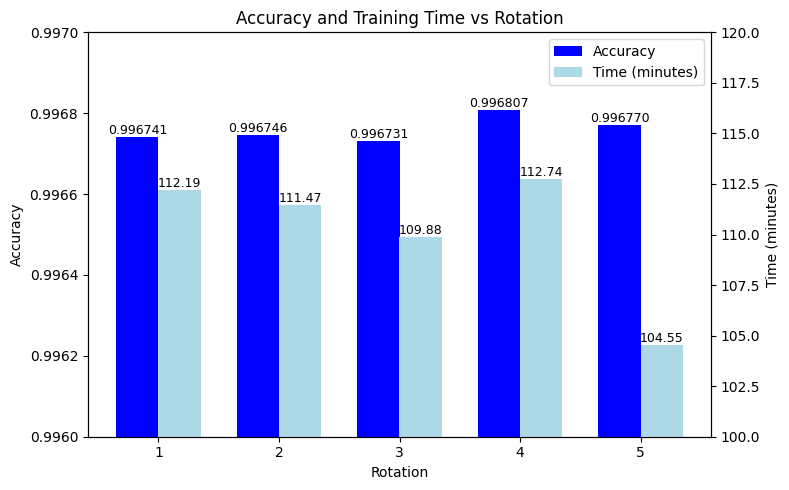

In [ ]:
# Rotation Accuracy vs Training Time Comparison
rotations = [1, 2, 3, 4, 5]
accuracy = [0.996741, 0.996746, 0.996731, 0.996807, 0.996770]
time_min = [112.19, 111.47, 109.88, 112.74, 104.55]

# X-axis positions for grouped bars
x = np.arange(len(rotations))
width = 0.35

# Create figure and primary axis (accuracy)
fig, ax1 = plt.subplots(figsize=(8, 5))

# Accuracy bars (left axis)
bars_acc = ax1.bar(
    x - width/2,
    accuracy,
    width,
    color='blue',
    label="Accuracy"
)
ax1.set_ylabel("Accuracy")
ax1.set_ylim(0.996, 0.997)
ax1.set_xlabel("Rotation")
ax1.set_xticks(x)
ax1.set_xticklabels(rotations)

# Training time bars (right axis)
ax2 = ax1.twinx()
bars_time = ax2.bar(
    x + width/2,
    time_min,
    width,
    color='lightblue',
    label="Time (minutes)"
)
ax2.set_ylabel("Time (minutes)")
ax2.set_ylim(100, 120)

# Annotate accuracy values
for idx, bar in enumerate(bars_acc):
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height, 
        f"{accuracy[idx]:.6f}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

# Annotate time values
for idx, bar in enumerate(bars_time):
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{time_min[idx]:.2f}",
        ha='center',
        va='bottom',
        fontsize=9,
        color='black'
    )

# Title and combined legend
plt.title("Accuracy and Training Time vs Rotation")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")

plt.tight_layout()
plt.show()


In [ ]:
# Load best trained RF model + selected features
BEST_MODEL = joblib.load("models/rf/tuning/rf_rotation_4.joblib")
FEATURES = joblib.load("models/rf/tuning/features_rotation_4.joblib")

# Extract model parameters
params = BEST_MODEL.get_params()

print(f"Params:\n{params}")
print(f"\nFeatures:\n{FEATURES}")

Params:
{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

Features:
['Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Segment Size Avg', 'Fwd Packet Length Min', 'Bwd Packets/s', 'FWD Init Win Bytes', 'Packet Length Mean', 'Total Bwd packets', 'Average Packet Size', 'Bwd Segment Size Avg', 'Bwd Init Win Bytes', 'Fwd Packet Length Max', 'Total Length of Fwd Packet', 'Packet Length Variance', 'Fwd Header Length', 'Flow IAT Min', 'Flow Bytes/s', 'Total Length of Bwd Packet', 'Dst Port', 'Packet Length Max', 'Bwd Packet Length Max', 'Packet Length Std', 'Fwd Packet Length Std', 'Bwd Packet Length Std', 'Subflow Fwd Bytes', 'Bwd I

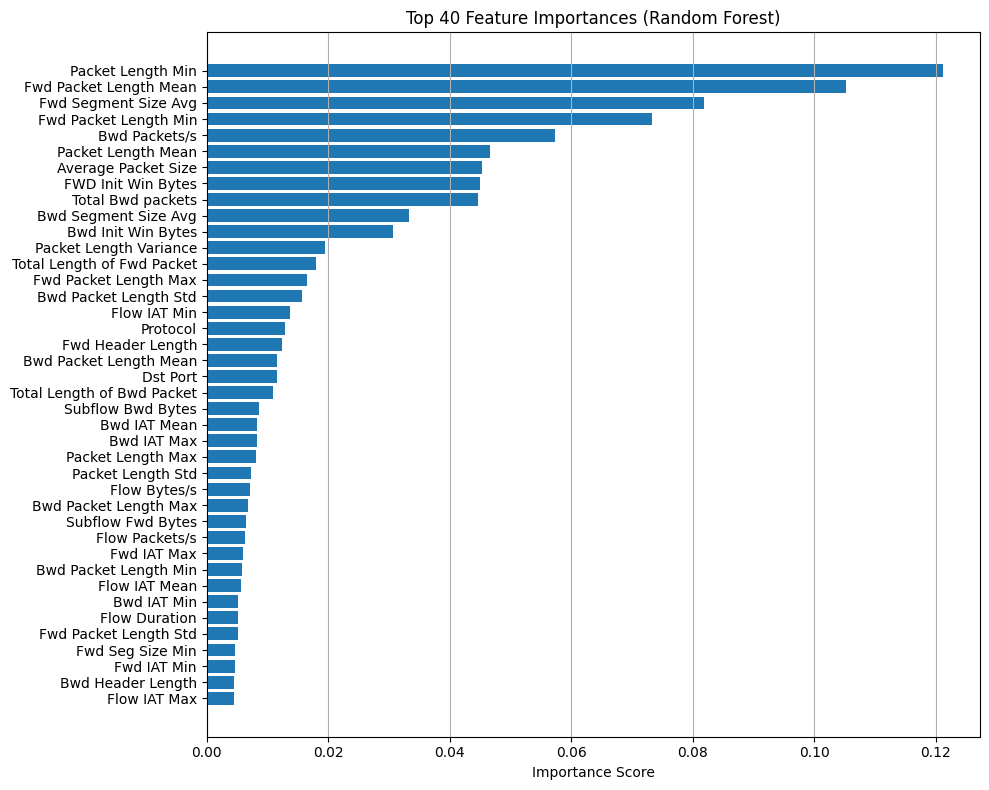

In [ ]:
# Feature Importance Extraction

# Map features to their importance scores
fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort features by importance and keep top 40
fi_df = (fi_df.sort_values("Importance", ascending=False).head(40))

# Plot feature importances
plt.figure(figsize=(10, 8))
plt.barh(fi_df["Feature"], fi_df["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Top 40 Feature Importances (Random Forest)")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

In [ ]:
def train_rf_model(LABEL, TRAIN_FILE, FEATURES=None, SCALER=False, PCA=False):
    """ 
    Trains a RF model on the given dataset and saves the trained model,
    encoder and optional obects such as scaler/PCA/features. 

    Parameters:
        LABEL (str): Model name used for directory structure
        TRAIN_FILE (str): Path to training dataset CSV
        FEATURES (list): Selected feature subset
        SCALER (bool): Whether to apply scaler
        PCA (bool): Whether to apply PCA dimensionality reduction     
    """
    
    # Create model output directory
    MODEL_DIR = f"models/rf/train/{LABEL}"
    os.makedirs(MODEL_DIR, exist_ok=True)
    
    # Define save paths
    MODEL_PATH = os.path.join(MODEL_DIR, f"final_model.joblib")
    SCALER_PATH = os.path.join(MODEL_DIR, f"scaler.joblib")
    PCA_PATH = os.path.join(MODEL_DIR, f"pca.joblib")
    FEATURES_PATH = os.path.join(MODEL_DIR, f"features.joblib")
    ENCODER_PATH = os.path.join(MODEL_DIR, f"encoder.joblib")
    FEATURE_IMPORTANCE_PATH = os.path.join(MODEL_DIR, f"sorted_features.joblib")
    
    # Model parameters
    params = {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 20, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 10, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}

    # Load and prepare data
    df = load_raw_data(TRAIN_FILE)

    # Split into features and labels
    X, Y = select_features(df, FEATURES)

    # Store original feature names before transformations
    feature_names = X.columns

    # Encode labels into numeric format
    Y, encoder = encode_labels(Y)

    # Apply feature scaling if enabled
    if SCALER != False:
        X, scaler = scale_features(X, method="standard")

    # Apply PCA if enabled
    if PCA != False:
        X, pca = apply_pca(X, n_components=23)
    
    # Model training
    print("\nTraining RF model...")
    start_time = time.time()

    # Initialise and train RF model
    rf = RandomForestClassifier(**params)
    rf.fit(X, Y)
    
    # Feature importance extraction
    importances = rf.feature_importances_

    # Sort features by importance
    sorted_indices = np.argsort(importances)[::-1]
    sorted_features = feature_names[sorted_indices].tolist()

    end_time = time.time()
    print(f"Training completed in {(end_time - start_time) / 60:.2f} minutes")

    # Save model and artifacts
    joblib.dump(rf, MODEL_PATH)
    joblib.dump(encoder, ENCODER_PATH)
    joblib.dump(feature_names, FEATURES_PATH)   
    if SCALER != False:
        joblib.dump(scaler, SCALER_PATH)
    if PCA != False:
        joblib.dump(pca, PCA_PATH)
    if LABEL == "ALL": joblib.dump(sorted_features, FEATURE_IMPORTANCE_PATH)


In [ ]:
def run_rf_validation(MODEL_DIR, VAL_FILE, FEATURES=False, SCALER=False, PCA=False):    
    """
    Runs validation on a trained RF model using chunked processing.
    Computes performance metrics (accuracy, confusion matrix, latency, throughput).

    Parameters:
        MODEL_DIR (str): Path to saved model directory
        VAL_FILE (str): Path to validation dataset CSV
        FEATURES (bool/list): Whether to use selected feature subset
        SCALER (bool): Whether scaler was used during training
        PCA (bool): Whether PCA was used during training
    """

    # Load trained model artifacts
    model = joblib.load(os.path.join(MODEL_DIR, "final_model.joblib"))
    encoder = joblib.load(os.path.join(MODEL_DIR, "encoder.joblib"))
    if FEATURES != False: features = joblib.load(os.path.join(MODEL_DIR, "features.joblib")) 
    if SCALER != False: scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.joblib")) 
    if PCA != False: pca = joblib.load(os.path.join(MODEL_DIR, "pca.joblib")) 

    print("Model loaded successfully.")

    # Storage for evaluation results
    y_true, y_pred = [], []
    y_true_bin, y_pred_bin = [], []

    total_inference_time = 0
    total_rows = 0

    # Read validation set in chunks
    for chunk in pd.read_csv(VAL_FILE, chunksize=500_000):

        # Encode true labels
        Y_chunk = chunk[TARGET_COL]
        Y_chunk = encoder.transform(Y_chunk)

        # Select features if provided
        if FEATURES != False:
            X_chunk = chunk[features]
        else:
            X_chunk = chunk.drop(columns=DROP_COLS, errors="ignore")

        # Apply pre-processing
        if SCALER != False:
            X_chunk = scaler.transform(X_chunk)

        if PCA != False:
            X_chunk = pca.transform(X_chunk)

        # Predict
        start_time = time.time()
        preds = model.predict(X_chunk)
        end_time = time.time()

        total_inference_time += (end_time - start_time)
        total_rows += len(X_chunk)

        # Convert predictions back to labels
        preds = encoder.inverse_transform(preds)
        Y_chunk = encoder.inverse_transform(Y_chunk)
        labels = encoder.classes_

        # Store multiclass results
        y_true.extend(Y_chunk)
        y_pred.extend(preds)

        # Convert to binary classification (Benign vs Attack)
        y_true_bin.extend([0 if y.lower() == "benign" else 1 for y in Y_chunk])
        y_pred_bin.extend([0 if y.lower() == "benign" else 1 for y in preds])


    # Latency & throughput metrics
    avg_latency_per_row = total_inference_time / total_rows
    latency_micros = avg_latency_per_row * 1_000_000
    throughput = total_rows / total_inference_time

    print(f"\nTotal Rows Processed:    {total_rows:,}")
    print(f"Total Inference Time:    {total_inference_time:.4f} seconds")
    print(f"Throughput:              {throughput:,.2f} rows/sec")
    print(f"Avg Latency per Row:     {latency_micros:.4f} μs")

    # Accuracy & reports
    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    print(f"\nBinary Detection Accuracy: {accuracy:.6f}")

    accuracy = accuracy_score(y_true, y_pred)
    print(f"Multi-Class Detection Accuracy: {accuracy:.6f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true_bin, y_pred_bin))
    print("\n")
    print(confusion_matrix(y_true, y_pred, labels=labels))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=labels, digits=4))

In [ ]:
# Experiment 1 - Using ALL features
train_rf_model(
    LABEL="ALL", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv"
)

Loading data...
Encoding Labels...

Training RF model...
Training completed in 42.49 minutes


In [ ]:
# Validation using ALL features
run_rf_validation(
    MODEL_DIR="models/rf/train/ALL", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    55.2732 seconds
Throughput:              167,389.65 rows/sec
Avg Latency per Row:     5.9741 μs

Binary Detection Accuracy: 0.996736
Multi-Class Detection Accuracy: 0.996580

Confusion Matrix:
[[2220350    9223]
 [  20974 7001618]]


[[2220350      63       1      91      90    4673    4126     179]
 [    238   21735       0       0       0       0       0       0]
 [     68       0   15536       0      11       0       0       0]
 [   2814       0       0 6875515       7       0       0       0]
 [    154       0       5       0   58539       0     503      10]
 [  16854       0       0       0       1    4051       0       0]
 [    818       0       0       0      20       0    8858      74]
 [     28       0       0       0       9       0     807   15937]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9906    0.9959    0.9932   2229573
    

In [ ]:
# Experiment 2 - Using 50% features from RF-based Feature Importance
sorted_features = joblib.load("models/rf/train/ALL/sorted_features.joblib")
total_count = len(sorted_features)
top_50_count = int(total_count * 0.5) + 1

FEATURES = sorted_features[:top_50_count]

train_rf_model(
    LABEL="50%_features", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    FEATURES=FEATURES,
    SCALER=True
)

Loading data...
Encoding Labels...
Applying scaler...

Training RF model...
Training completed in 35.47 minutes


In [ ]:
# Validation using 50% features
run_rf_validation(
    MODEL_DIR="models/rf/train/50%_features", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    42.6460 seconds
Throughput:              216,952.75 rows/sec
Avg Latency per Row:     4.6093 μs

Binary Detection Accuracy: 0.996879
Multi-Class Detection Accuracy: 0.996763

Confusion Matrix:
[[2220618    8955]
 [  19925 7002667]]


[[2220618      80       2      80      34    4641    3923     195]
 [    149   21824       0       0       0       0       0       0]
 [     78       0   15535       2       0       0       0       0]
 [   1676       0       0 6876630      30       0       0       0]
 [    272       0       0      21   58416       0     493       9]
 [  16884       0       0       0       0    4022       0       0]
 [    859       0       0       0      20       0    8809      82]
 [      7       0       0       0       7       0     403   16364]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9911    0.9960    0.9935   2229573
    

In [ ]:
# Experiment 3 - Using 25% features from RF-based Feature Importance
sorted_features = joblib.load("models/rf/train/ALL/sorted_features.joblib")
total_count = len(sorted_features)
top_25_count = int(total_count * 0.25) + 1

FEATURES = sorted_features[:top_25_count]

train_rf_model(
    LABEL="25%_features", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    FEATURES=FEATURES,
    SCALER=True
)

Loading data...
Encoding Labels...
Applying scaler...

Training RF model...
Training completed in 25.95 minutes


In [ ]:
# Validation using 25% features
run_rf_validation(
    MODEL_DIR="models/rf/train/25%_features", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    37.7835 seconds
Throughput:              244,873.17 rows/sec
Avg Latency per Row:     4.0837 μs

Binary Detection Accuracy: 0.996996
Multi-Class Detection Accuracy: 0.996886

Confusion Matrix:
[[2220872    8701]
 [  19096 7003496]]


[[2220872      66       3     149     252    5325    2711     195]
 [     76   21897       0       0       0       0       0       0]
 [     25       0   15560      18      12       0       0       0]
 [   1048       0       1 6877278       6       2       1       0]
 [     75       0       5       0   58679       0     447       5]
 [  16598       0       0       3       1    4304       0       0]
 [   1270       0       0       3      22       0    8398      77]
 [      4       0       0       0      10       0     401   16366]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9915    0.9961    0.9938   2229573
    

In [ ]:
# Experiment 4 - Using 90% variance PCA
train_rf_model(
    LABEL="90%_PCA", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    SCALER=True,
    PCA=True
)

Loading data...
Encoding Labels...
Applying scaler...
Appling PCA...

Training RF model...
Training completed in 71.11 minutes


In [ ]:
# Validation using 90% PCA
run_rf_validation(
    MODEL_DIR="models/rf/train/90%_PCA", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True,
    PCA=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    41.3891 seconds
Throughput:              223,541.16 rows/sec
Avg Latency per Row:     4.4734 μs

Binary Detection Accuracy: 0.996920
Multi-Class Detection Accuracy: 0.996691

Confusion Matrix:
[[2220712    8861]
 [  19637 7002955]]


[[2220712      66      16     422     102    4668    3226     361]
 [    140   21833       0       0       0       0       0       0]
 [     45       0   15557       1      10       0       1       1]
 [   1139       0       8 6876285     777       0     110      17]
 [    226       0       5      27   58496       0     445      12]
 [  16881       0       0       2       1    4021       0       1]
 [   1173       0       2     137      26       0    8338      94]
 [     33       0       0       0       7       0     434   16307]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9912    0.9960    0.9936   2229573
    

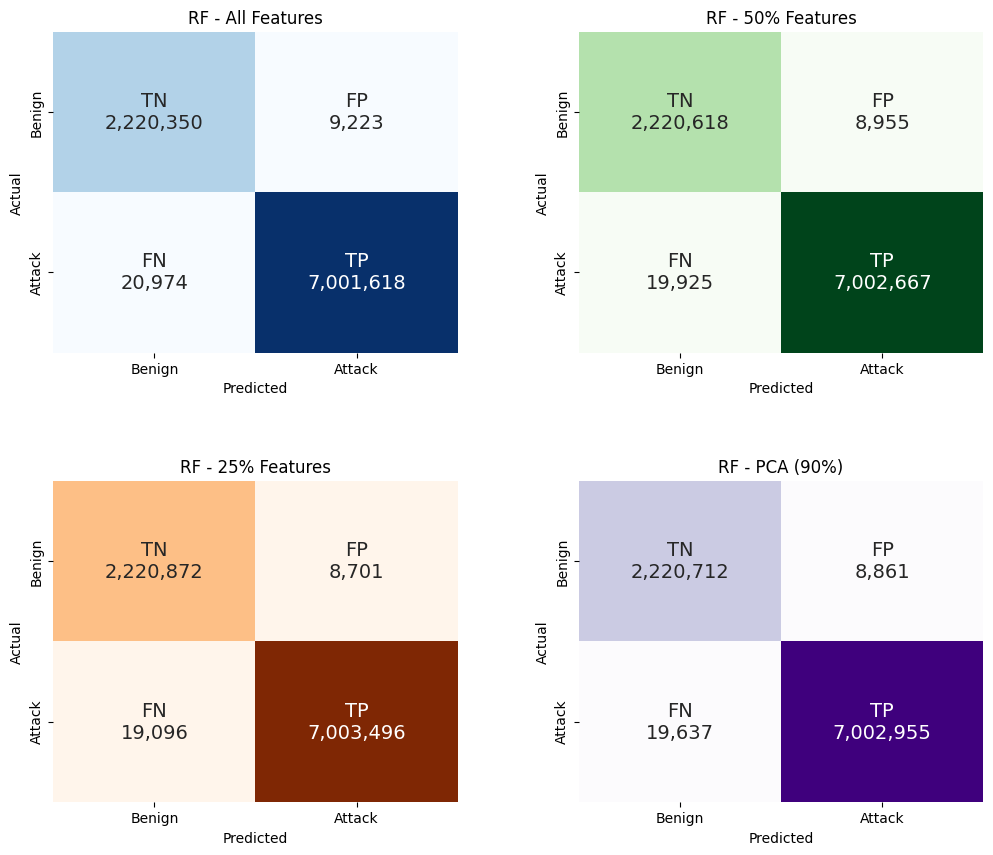

In [13]:
cm_all = np.array([[2220350, 9223], [ 20974, 7001618]]) 
cm_50 = np.array([[2220618, 8955], [ 19925, 7002667]]) 
cm_25 = np.array([[2220872, 8701], [ 19096, 7003496]]) 
cm_pca = np.array([[2220712, 8861], [ 19637, 7002955]])

plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
plot_cm(cm_all, plt.gca(), "RF - All Features", "Blues")

plt.subplot(2, 2, 2)
plot_cm(cm_50, plt.gca(), "RF - 50% Features", "Greens")

plt.subplot(2, 2, 3)
plot_cm(cm_25, plt.gca(), "RF - 25% Features", "Oranges")

plt.subplot(2, 2, 4)
plot_cm(cm_pca, plt.gca(), "RF - PCA (90%)", "Purples")

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

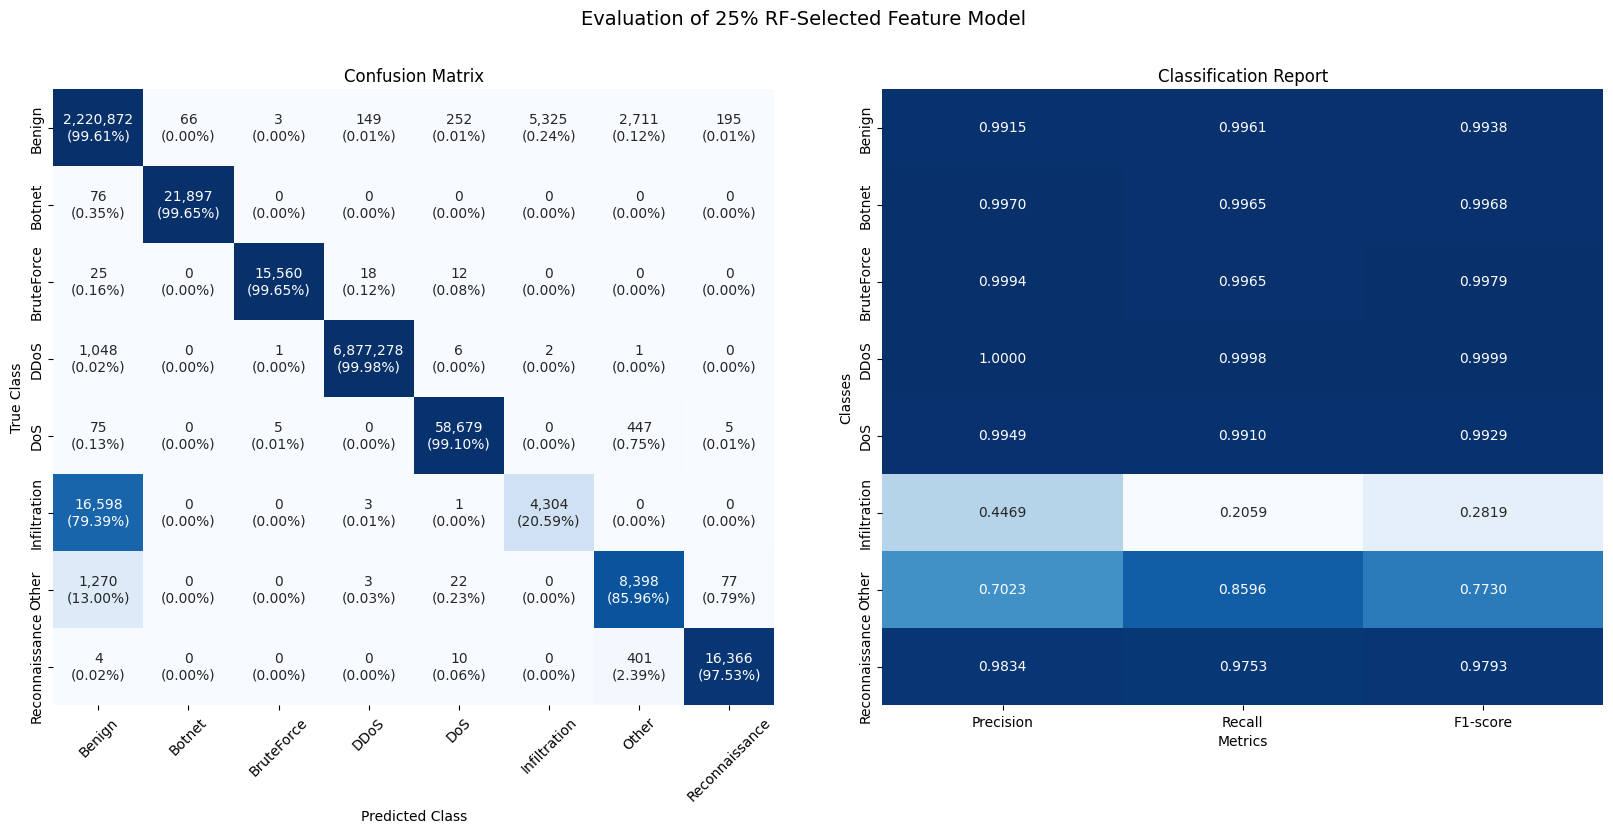

In [14]:
cm = np.array([
    [2220872, 66, 3, 149, 252, 5325, 2711, 195],
    [76, 21897, 0, 0, 0, 0, 0, 0],
    [25, 0, 15560, 18, 12, 0, 0, 0],
    [1048, 0, 1, 6877278, 6, 2, 1, 0],
    [75, 0, 5, 0, 58679, 0, 447, 5],
    [16598, 0, 0, 3, 1, 4304, 0, 0],
    [1270, 0, 0, 3, 22, 0, 8398, 77],
    [4, 0, 0, 0, 10, 0, 401, 16366]
])

labels = [
    "Benign", "Botnet", "BruteForce", "DDoS",
    "DoS", "Infiltration", "Other", "Reconnaissance"
]

precision = [0.9915, 0.9970, 0.9994, 1.0000, 0.9949, 0.4469, 0.7023, 0.9834]
recall    = [0.9961, 0.9965, 0.9965, 0.9998, 0.9910, 0.2059, 0.8596, 0.9753]
f1_score  = [0.9938, 0.9968, 0.9979, 0.9999, 0.9929, 0.2819, 0.7730, 0.9793]

plot_model_evaluation_figure(
    cm=cm,
    class_labels=labels,
    precision=precision,
    recall=recall,
    f1_score=f1_score,
    figure_title="Evaluation of 25% RF-Selected Feature Model"
)

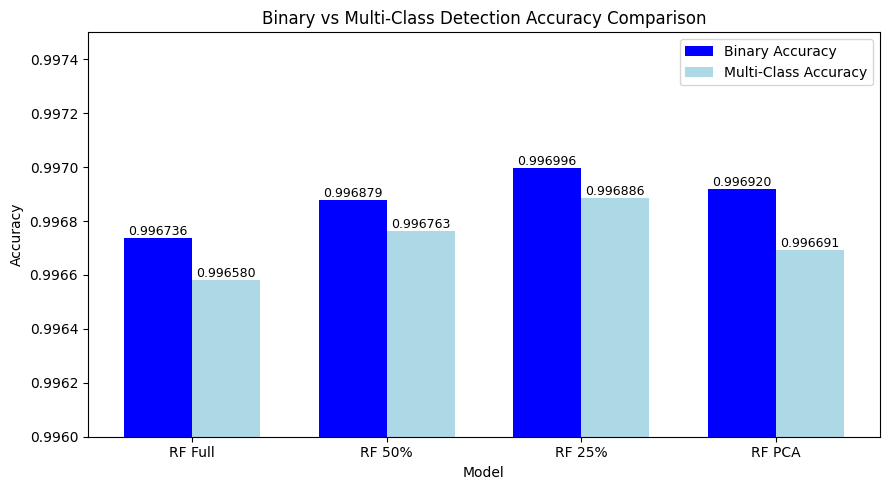

In [15]:
models = ["RF Full", "RF 50%", "RF 25%", "RF PCA"]

binary_acc = [
    0.996736,
    0.996879,
    0.996996,
    0.996920
]

multiclass_acc = [
    0.996580,
    0.996763,
    0.996886,
    0.996691
]

plot_accuracy_comparison(models, binary_acc, multiclass_acc)

Deep Neural Network (DNN)

In [ ]:
def train_dnn_model(LABEL, TRAIN_FILE, FEATURES=None, SCALER=False, PCA=False):
    """
    Trains a DNN model on the given dataset and saves the trained model,
    encoder and optional objects such as scaler/PCA/features. 

    Parameters:
        LABEL (str): Model label used for directory structure
        TRAIN_FILE (str): Path to training dataset
        FEATURES (list): Selected feature subset
        SCALER (bool): Whether to apply scaler
        PCA (bool): Whether to apply PCA dimensionality reduction
    """

    # Create model directory
    MODEL_DIR = f"models/dnn/train/{LABEL}"
    os.makedirs(MODEL_DIR, exist_ok=True)
    
    # Save paths for model artifacts
    MODEL_PATH = os.path.join(MODEL_DIR, f"final_model.keras")
    SCALER_PATH = os.path.join(MODEL_DIR, f"scaler.joblib")
    PCA_PATH = os.path.join(MODEL_DIR, f"pca.joblib")
    FEATURES_PATH = os.path.join(MODEL_DIR, f"features.joblib")
    ENCODER_PATH = os.path.join(MODEL_DIR, f"encoder.joblib")
    
    # Load and pre-process data
    df = load_raw_data(TRAIN_FILE)

    # Split into features and labels
    X, Y = select_features(df, FEATURES)

    # Store original feature names
    feature_names = X.columns

    # Encode target labels
    Y, encoder = encode_labels(Y)

    # Apply scaling if enabled
    if SCALER != False:
        X, scaler = scale_features(X, method="standard")

    # Apply PCA if enabled
    if PCA != False:
        X, pca = apply_pca(X, n_components=23)
    
    print("\nTraining DNN model...")

    # Build DNN model
    num_classes = len(np.unique(Y))

    model = Sequential([
        Input(shape=(X.shape[1],)),

        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.4),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation="relu"),
        BatchNormalization(),
        Dropout(0.2),

        Dense(num_classes, activation="softmax") 
    ])

    # Compile model
    model.compile(
        optimizer="Adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping to prevent overfitting
    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    # Model training
    start_time = time.time()

    history = model.fit(
        X,
        Y,
        validation_split=0.1,
        epochs=50,
        batch_size=8192,
        callbacks=[early_stop],
        verbose=1
        )

    end_time = time.time()
    print(f"\nTraining completed in {(end_time - start_time) / 60:.2f} minutes")

    # Save model and artifacts
    model.save(MODEL_PATH)
    joblib.dump(encoder, ENCODER_PATH)
    joblib.dump(feature_names, FEATURES_PATH)   
    if SCALER != False:
        joblib.dump(scaler, SCALER_PATH)
    if PCA != False:
        joblib.dump(pca, PCA_PATH)

    return history

In [ ]:
def run_dnn_validation(MODEL_DIR, VAL_FILE, FEATURES=False, SCALER=False, PCA=False):  
    """
    Evaluates a trained DNN model on validation dataset using chunked processing.
    Computes performance metrics (accuracy, confusion matrix, latency, throughput).

    Parameters:
        MODEL_DIR (str): Path to saved model directory
        VAL_FILE (str): Path to validation dataset CSV
        FEATURES (bool): Whether to use selected feature subset
        SCALER (bool): Whether scaler was used during training
        PCA (bool): Whether PCA was used during training
    """
          
    # Load trained model and artifacts
    model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_model.keras"))
    encoder = joblib.load(os.path.join(MODEL_DIR, "encoder.joblib"))
    if FEATURES != False: features = joblib.load(os.path.join(MODEL_DIR, "features.joblib")) 
    if SCALER != False: scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.joblib")) 
    if PCA != False: pca = joblib.load(os.path.join(MODEL_DIR, "pca.joblib")) 

    print("Model loaded successfully.")

    # Storage for predictions
    y_true, y_pred = [], []
    y_true_bin, y_pred_bin = [], []

    total_inference_time = 0
    total_rows = 0

    # Read validation set in chunks
    for chunk in pd.read_csv(VAL_FILE, chunksize=500_000):

        # Encode labels
        Y_chunk = chunk[TARGET_COL]
        Y_chunk = encoder.transform(Y_chunk)

        # Select features if provided
        if FEATURES != False:
            X_chunk = chunk[features]
        else:
            X_chunk = chunk.drop(columns=DROP_COLS, errors="ignore")

        # Apply pre-processing
        if SCALER != False:
            X_chunk = scaler.transform(X_chunk)

        if PCA != False:
            X_chunk = pca.transform(X_chunk)

        # Predict probabilities
        start_time = time.time()
        y_probs = model.predict(
            X_chunk,
            batch_size=8192,
            verbose=0
        )

        # Convert probabilities to class predictions
        preds = np.argmax(y_probs, axis=1)
        end_time = time.time()

        total_inference_time += (end_time - start_time)
        total_rows += len(X_chunk)

        # Convert back to original labels
        preds = encoder.inverse_transform(preds)
        Y_chunk = encoder.inverse_transform(Y_chunk)
        labels = encoder.classes_

        # Store multiclass results
        y_true.extend(Y_chunk)
        y_pred.extend(preds)

        # Convert to binary classification (Benign vs Attack)
        y_true_bin.extend([0 if y.lower() == "benign" else 1 for y in Y_chunk])
        y_pred_bin.extend([0 if y.lower() == "benign" else 1 for y in preds])


    # Latency & throughput metrics
    avg_latency_per_row = total_inference_time / total_rows
    latency_micros = avg_latency_per_row * 1_000_000
    throughput = total_rows / total_inference_time

    print(f"\nTotal Rows Processed:    {total_rows:,}")
    print(f"Total Inference Time:    {total_inference_time:.4f} seconds")
    print(f"Throughput:              {throughput:,.2f} rows/sec")
    print(f"Avg Latency per Row:     {latency_micros:.4f} μs")

    # Accuracy & reports
    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    print(f"\nBinary Detection Accuracy: {accuracy:.6f}")

    accuracy = accuracy_score(y_true, y_pred)
    print(f"Multi-Class Detection Accuracy: {accuracy:.6f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true_bin, y_pred_bin))
    print("\n")
    print(confusion_matrix(y_true, y_pred, labels=labels))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=labels, digits=4))

In [ ]:
# Experiment 1 - Using ALL features
DNN_1 = train_dnn_model(
    LABEL="ALL", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    SCALER=True
)

Loading data...
Encoding Labels...
Applying scaler...

Training DNN model...
Epoch 1/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 120s 105ms/step - accuracy: 0.9546 - loss: 0.1608 - val_accuracy: 0.9929 - val_loss: 0.0270
Epoch 2/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 117s 105ms/step - accuracy: 0.9725 - loss: 0.0934 - val_accuracy: 0.9935 - val_loss: 0.0232
Epoch 3/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 116s 105ms/step - accuracy: 0.9749 - loss: 0.0843 - val_accuracy: 0.9962 - val_loss: 0.0184
Epoch 4/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 117s 106ms/step - accuracy: 0.9764 - loss: 0.0786 - val_accuracy: 0.9927 - val_loss: 0.0238
Epoch 5/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 117s 106ms/step - accuracy: 0.9773 - loss: 0.0751 - val_accuracy: 0.9957 - val_loss: 0.0198
Epoch 6/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 117s 106ms/step - accuracy: 0.9780 - loss: 0.0728 - val_accuracy: 0.9843 - val_loss: 0.0297
Epoch 7/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 119s 107ms/step - accuracy: 0.9786 - loss: 0.0709 - val_accuracy: 0.9961 - va

In [ ]:
# Validation using ALL features
run_dnn_validation(
    MODEL_DIR="models/dnn/train/ALL", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    22.9036 seconds
Throughput:              403,960.43 rows/sec
Avg Latency per Row:     2.4755 μs

Binary Detection Accuracy: 0.994041
Multi-Class Detection Accuracy: 0.993475

Confusion Matrix:
[[2198254   31319]
 [  23818 6998774]]


[[2198254     147      15    1675   15158    4599    5428    4297]
 [    214   21759       0       0       0       0       0       0]
 [    154       0   15448       1      11       0       0       1]
 [   5426       0       2 6870517    2301       6      32      52]
 [    272       0       0       6   58338       0     582      13]
 [  17218       0       0      65     276    3347       0       0]
 [    490       0       0     150       0       0    8566     564]
 [     44       0       0       2      17       0    1152   15566]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9893    0.9860    0.9876   2229573
    

In [ ]:
# Experiment 2 - Using 90% variance PCA
DNN_2 = train_dnn_model(
    LABEL="90%_PCA", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    SCALER=True,
    PCA=True
)

Loading data...
Encoding Labels...
Applying scaler...
Appling PCA...

Training DNN model...
Epoch 1/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 105s 91ms/step - accuracy: 0.9448 - loss: 0.1932 - val_accuracy: 0.9805 - val_loss: 0.0523
Epoch 2/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 102s 92ms/step - accuracy: 0.9692 - loss: 0.1052 - val_accuracy: 0.9903 - val_loss: 0.0333
Epoch 3/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 110s 99ms/step - accuracy: 0.9724 - loss: 0.0941 - val_accuracy: 0.9903 - val_loss: 0.0327
Epoch 4/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 100s 90ms/step - accuracy: 0.9740 - loss: 0.0883 - val_accuracy: 0.9957 - val_loss: 0.0196
Epoch 5/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 96s 86ms/step - accuracy: 0.9751 - loss: 0.0843 - val_accuracy: 0.9853 - val_loss: 0.0293
Epoch 6/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 119s 108ms/step - accuracy: 0.9758 - loss: 0.0817 - val_accuracy: 0.9946 - val_loss: 0.0257
Epoch 7/50
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 120s 108ms/step - accuracy: 0.9764 - loss: 0.0799 - val_accuracy: 0.

In [ ]:
# Validation using 90% PCA
run_dnn_validation(
    MODEL_DIR="models/dnn/train/90%_PCA", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True,
    PCA=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    21.4078 seconds
Throughput:              432,185.91 rows/sec
Avg Latency per Row:     2.3138 μs

Binary Detection Accuracy: 0.992907
Multi-Class Detection Accuracy: 0.991974

Confusion Matrix:
[[2191534   38039]
 [  27584 6995008]]


[[2191534      34      13    6010   16714    2793    6943    5532]
 [    534   21439       0       0       0       0       0       0]
 [    531       0   15068       0       3       0       0      13]
 [   6177       0     221 6867290    3936       0     493     219]
 [    661       0       0     643   57314       0     586       7]
 [  18256       1       0      71     317    2186       0      75]
 [    623       0       0     241       0       0    8906       0]
 [    802       0       0      12      17       0    1784   14166]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9876    0.9829    0.9852   2229573
    

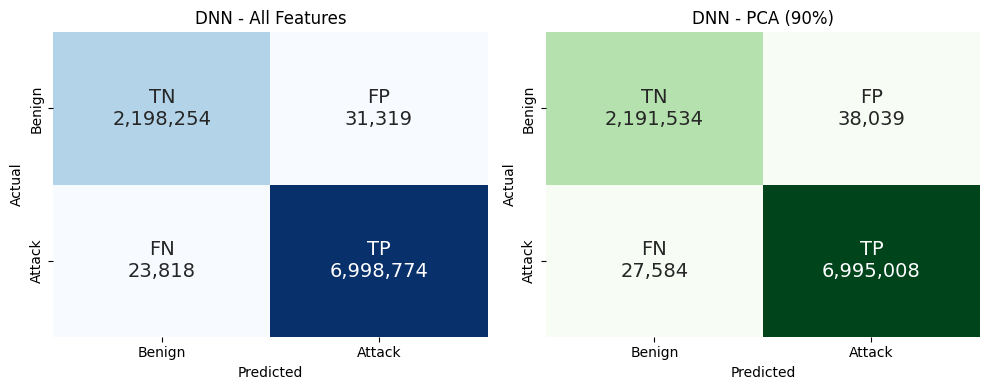

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_full = np.array([
    [2198254, 31319],
    [23818, 6998774]
])

cm_pca = np.array([
    [2191534, 38039],
    [27584, 6995008]
])

plot_cm(cm_full, axes[0], "DNN - All Features", "Blues")
plot_cm(cm_pca, axes[1], "DNN - PCA (90%)", "Greens")

plt.tight_layout()
plt.show()

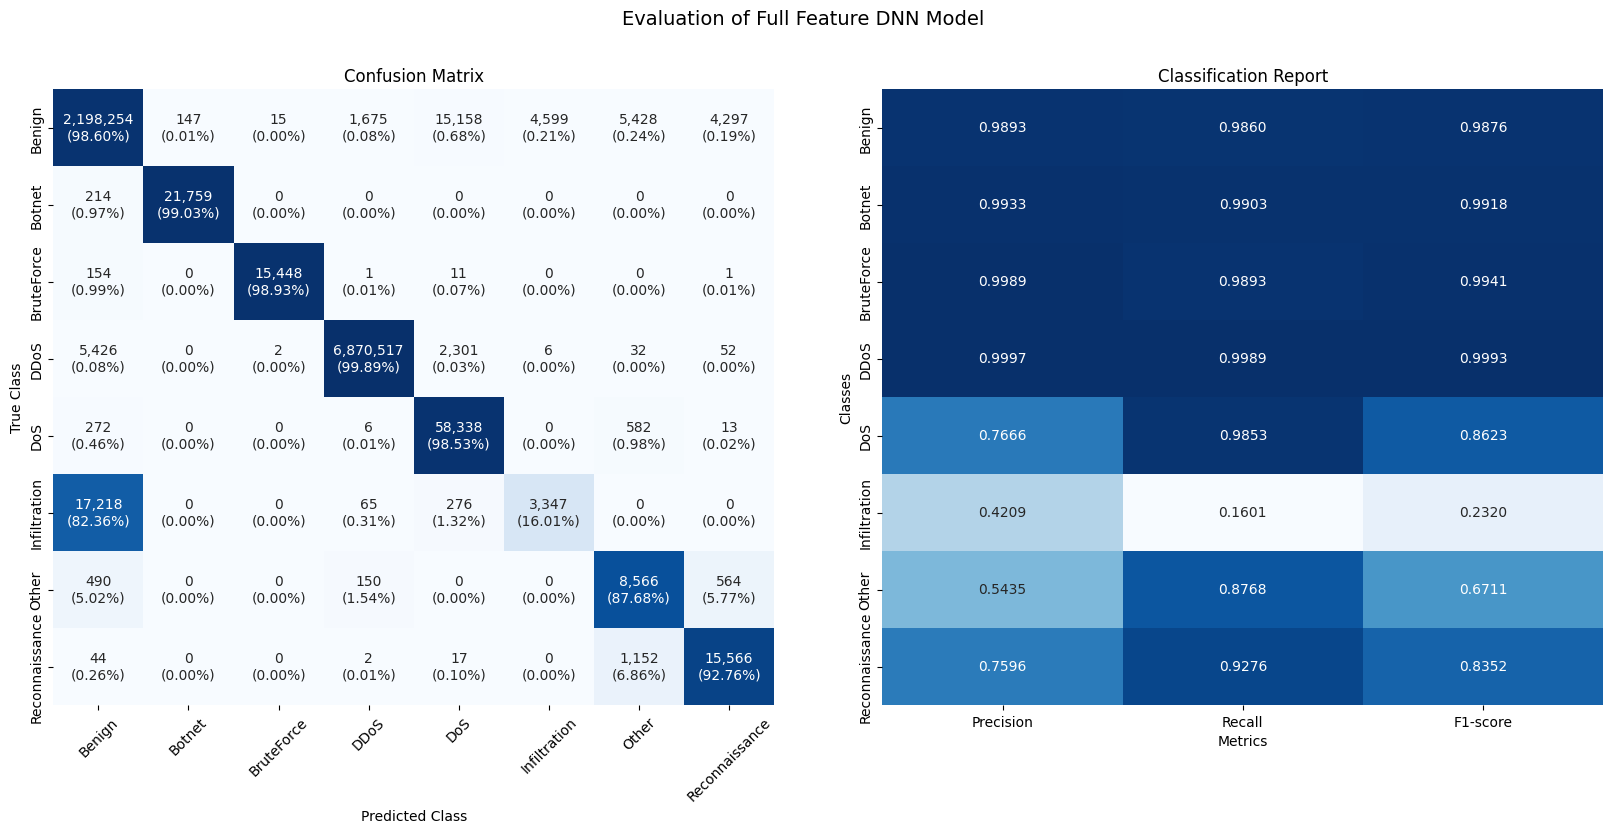

In [18]:
cm_multi = [
    [2198254, 147, 15, 1675, 15158, 4599, 5428, 4297],
    [214, 21759, 0, 0, 0, 0, 0, 0],
    [154, 0, 15448, 1, 11, 0, 0, 1],
    [5426, 0, 2, 6870517, 2301, 6, 32, 52],
    [272, 0, 0, 6, 58338, 0, 582, 13],
    [17218, 0, 0, 65, 276, 3347, 0, 0],
    [490, 0, 0, 150, 0, 0, 8566, 564],
    [44, 0, 0, 2, 17, 0, 1152, 15566]
]

labels = [
    "Benign", "Botnet", "BruteForce", "DDoS",
    "DoS", "Infiltration", "Other", "Reconnaissance"
]

precision = [0.9893, 0.9933, 0.9989, 0.9997, 0.7666, 0.4209, 0.5435, 0.7596]
recall    = [0.9860, 0.9903, 0.9893, 0.9989, 0.9853, 0.1601, 0.8768, 0.9276]
f1_score  = [0.9876, 0.9918, 0.9941, 0.9993, 0.8623, 0.2320, 0.6711, 0.8352]

plot_model_evaluation_figure(
    cm=cm_multi,
    class_labels=labels,
    precision=precision,
    recall=recall,
    f1_score=f1_score,
    figure_title="Evaluation of Full Feature DNN Model"
)

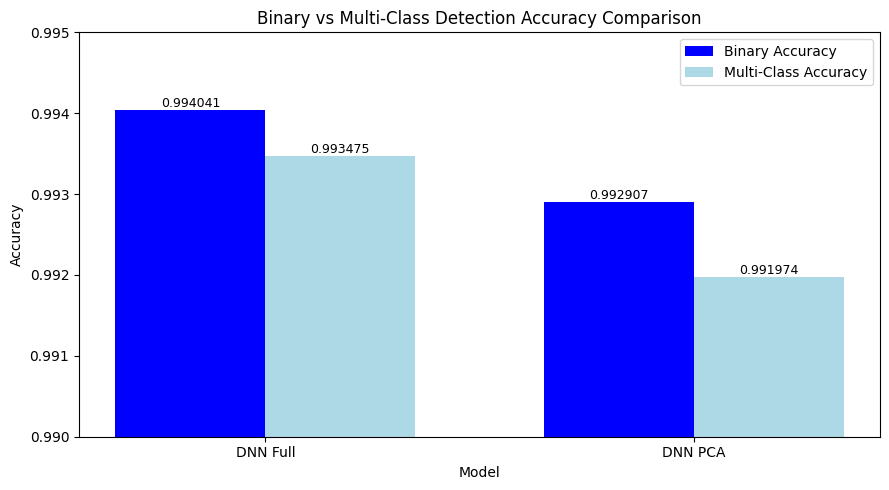

In [ ]:
models = ["DNN Full", "DNN PCA"]

binary_acc = [
    0.994041,
    0.992907
]

multiclass_acc = [
    0.993475,
    0.991974
]

plot_accuracy_comparison(models, binary_acc, multiclass_acc)

Long Short Term Memory (LSTM)

In [ ]:
def train_lstm_model(LABEL, TRAIN_FILE, FEATURES=None, SCALER=False, PCA=False):
    """ 
    Trains an LSTM model sequential data using sliding time windows
    on the given dataset and saves the trained model,
    encoder and optional objects such as scaler/PCA/features. 

    Parameters:
        LABEL (str): Model name used for directory structure
        TRAIN_FILE (str): Path to training dataset CSV
        FEATURES (list): Selected feature subset
        SCALER (bool): Whether to apply scaler
        PCA (bool): Whether to apply PCA dimensionality reduction     
    """
    
    # Create model directory
    MODEL_DIR = f"models/lstm/train/{LABEL}"
    os.makedirs(MODEL_DIR, exist_ok=True)
    
    # Save paths for model artifacts
    MODEL_PATH = os.path.join(MODEL_DIR, f"final_model.keras")
    SCALER_PATH = os.path.join(MODEL_DIR, f"scaler.joblib")
    PCA_PATH = os.path.join(MODEL_DIR, f"pca.joblib")
    FEATURES_PATH = os.path.join(MODEL_DIR, f"features.joblib")
    ENCODER_PATH = os.path.join(MODEL_DIR, f"encoder.joblib")
    
    # LSTM configuration
    TIME_STEPS = 10   # 10 consecutive flows as one sequence
    BATCH_SIZE = 8192

    # Load and pre-process data
    df = load_raw_data(TRAIN_FILE)
    
    # Split into features and labels
    X, Y = select_features(df, FEATURES)

    # Store feature names before transformation
    feature_names = X.columns

    # Encode labels
    Y, encoder = encode_labels(Y)

    # Apply scaling if enabled
    if SCALER != False:
        X, scaler = scale_features(X, method="standard")

    # Apply PCA if enabled
    if PCA != False:
        X, pca = apply_pca(X, n_components=23)

    # Create LSTM time-series dataset
    train_dataset = tf.keras.utils.timeseries_dataset_from_array(
        data=X,                         # Training data
        targets=Y[TIME_STEPS-1:],       # Align label with sliding window
        sequence_length=TIME_STEPS,     # TIME_STEPS rows per sequence
        sequence_stride=1,              # Overlapping sliding windows
        batch_size=BATCH_SIZE,          # Number of sequences per training batch
        shuffle=True                    # Randomise order of sequences 
    ).prefetch(tf.data.AUTOTUNE)

    print("\nTraining LSTM model...")

    # Build LSTM model
    num_classes = len(np.unique(Y))

    model = Sequential([
        Input(shape=(None, X.shape[1])),

        # First LSTM layer
        LSTM(64, return_sequences=True),
        BatchNormalization(),
        Dropout(0.2),
        
        # Second LSTM layer
        LSTM(32, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        
        Dense(16, activation='relu'),

        Dense(num_classes, activation="softmax") 
    ])

    # Compile model
    model.compile(
        optimizer="Adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    # Early stopping
    early_stop = EarlyStopping(monitor='loss', patience=5, restore_best_weights=True) 

    # Model training
    start_time = time.time()

    history = model.fit(
        train_dataset,
        epochs=50, 
        callbacks=[early_stop],
        verbose=1
    )

    end_time = time.time()
    print(f"\nTraining completed in {(end_time - start_time) / 60:.2f} minutes")

    # Save model and artifacts
    model.save(MODEL_PATH)
    joblib.dump(encoder, ENCODER_PATH)
    joblib.dump(feature_names, FEATURES_PATH)   
    if SCALER != False:
        joblib.dump(scaler, SCALER_PATH)
    if PCA != False:
        joblib.dump(pca, PCA_PATH)

    return history

In [ ]:
def create_sequences(data, window):
    """ Converts data into overlapping sliding window sequences for LSTM input """

    # Compute output shape: (num_sequences, window, num_features)
    shape = (data.shape[0] - window + 1, window, data.shape[1])
    
    # Stride settings to create overlapping windows without copying data
    strides = (data.strides[0], data.strides[0], data.strides[1])
    return np.lib.stride_tricks.as_strided(data, shape=shape, strides=strides)

def run_lstm_validation(MODEL_DIR, VAL_FILE, FEATURES=False, SCALER=False, PCA=False, window=10):  
    """
    Evaluates a trained LSTM model on validation dataset using chunked processing.
    Computes performance metrics (accuracy, confusion matrix, latency, throughput).

    Parameters:
        MODEL_DIR (str): Path to saved model directory
        VAL_FILE (str): Path to validation dataset CSV
        FEATURES (bool): Whether to use selected feature subset
        SCALER (bool): Whether scaler was used during training
        PCA (bool): Whether PCA was used during training
        window (int): Sequence length for LSTM input
    """
          
    # Load model and artifacts
    model = tf.keras.models.load_model(os.path.join(MODEL_DIR, "final_model.keras"))
    encoder = joblib.load(os.path.join(MODEL_DIR, "encoder.joblib"))
    if FEATURES != False: features = joblib.load(os.path.join(MODEL_DIR, "features.joblib")) 
    if SCALER != False: scaler = joblib.load(os.path.join(MODEL_DIR, "scaler.joblib")) 
    if PCA != False: pca = joblib.load(os.path.join(MODEL_DIR, "pca.joblib")) 

    print("Model loaded successfully.")

    # Storage for evaluation results
    y_true, y_pred = [], []
    y_true_bin, y_pred_bin = [], []

    total_inference_time = 0
    total_rows = 0

    # Read validation set in chunks
    for chunk in pd.read_csv(VAL_FILE, chunksize=500_000):

        # Encode labels
        Y_chunk = chunk[TARGET_COL]
        Y_chunk = encoder.transform(Y_chunk)

        # Select features if provided
        if FEATURES != False:
            X_chunk = chunk[features]
        else:
            X_chunk = chunk.drop(columns=DROP_COLS, errors="ignore")

        # Apply pre-processing
        if SCALER != False:
            X_chunk = scaler.transform(X_chunk)

        if PCA != False:
            X_chunk = pca.transform(X_chunk)

        # Build LSTM windows
        # Pad beginning so first rows can form full windows
        pad = np.repeat(X_chunk[:1], window - 1, axis=0)
        padded_data = np.vstack([pad, X_chunk])

        # Convert into sequences
        sequences = create_sequences(padded_data, window)

        # Predict probabilities
        start_time = time.time()
        y_probs = model.predict(
            sequences,
            batch_size=8192,
            verbose=0
        )

        preds = np.argmax(y_probs, axis=1)
        end_time = time.time()

        total_inference_time += (end_time - start_time)
        total_rows += len(X_chunk)

        # Convert back to original labels
        preds = encoder.inverse_transform(preds)
        Y_chunk = encoder.inverse_transform(Y_chunk)
        labels = encoder.classes_

        # Store multiclass results
        y_true.extend(Y_chunk)
        y_pred.extend(preds)

        # Convert to binary classification (Benign vs Attack)
        y_true_bin.extend([0 if y.lower() == "benign" else 1 for y in Y_chunk])
        y_pred_bin.extend([0 if y.lower() == "benign" else 1 for y in preds])


    # Latency & throughput metrics
    avg_latency_per_row = total_inference_time / total_rows
    latency_micros = avg_latency_per_row * 1_000_000
    throughput = total_rows / total_inference_time

    print(f"\nTotal Rows Processed:    {total_rows:,}")
    print(f"Total Inference Time:    {total_inference_time:.4f} seconds")
    print(f"Throughput:              {throughput:,.2f} rows/sec")
    print(f"Avg Latency per Row:     {latency_micros:.4f} μs")

    # Accuracy & reports
    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    print(f"\nBinary Detection Accuracy: {accuracy:.6f}")

    accuracy = accuracy_score(y_true, y_pred)
    print(f"Multi-Class Detection Accuracy: {accuracy:.6f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true_bin, y_pred_bin))
    print("\n")
    print(confusion_matrix(y_true, y_pred, labels=labels))

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, labels=labels, digits=4))

In [ ]:
# Experiment 1 - Using ALL Features
LSTM_1 = train_lstm_model(
    LABEL="ALL", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    SCALER=True
)

Loading data...
Encoding Labels...
Applying scaler...

Training LSTM model...
Epoch 1/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1081s 852ms/step - accuracy: 0.9558 - loss: 0.1603
Epoch 2/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1057s 862ms/step - accuracy: 0.9833 - loss: 0.0448
Epoch 3/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1072s 873ms/step - accuracy: 0.9851 - loss: 0.0378
Epoch 4/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1085s 885ms/step - accuracy: 0.9859 - loss: 0.0344
Epoch 5/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1096s 894ms/step - accuracy: 0.9867 - loss: 0.0319
Epoch 6/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1076s 878ms/step - accuracy: 0.9873 - loss: 0.0299
Epoch 7/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1077s 879ms/step - accuracy: 0.9878 - loss: 0.0285
Epoch 8/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1081s 882ms/step - accuracy: 0.9881 - loss: 0.0276
Epoch 9/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1084s 884ms/step - accuracy: 0.9883 - loss: 0.0269
Epoch 10/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1105s 901ms/step - accuracy: 0.9884 - loss

In [ ]:
# Validation using ALL features
run_lstm_validation(
    MODEL_DIR="models/lstm/train/ALL", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    284.1215 seconds
Throughput:              32,564.11 rows/sec
Avg Latency per Row:     30.7087 μs

Binary Detection Accuracy: 0.997185
Multi-Class Detection Accuracy: 0.996973

Confusion Matrix:
[[2217563   12010]
 [  14039 7008553]]


[[2217563      58      32     199     601    5146    5331     643]
 [    187   21784       0       0       0       2       0       0]
 [     74       0   15537       0       0       0       0       4]
 [   1054       0       0 6877258      21       0       0       3]
 [    393       0       2       2   58220       2     582      10]
 [  11562       1       0       0       0    9343       0       0]
 [    691       0       1       0       3       0    8727     348]
 [     78       0       0       2       1       0     970   15730]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9937    0.9946    0.9942   2229573
   

In [ ]:
# Experiment 2 - Using 90% PCA
LSTM_2 = train_lstm_model(
    LABEL="90%_PCA", 
    TRAIN_FILE="data/cleaned/partitioned/balanced_train.csv",
    SCALER=True,
    PCA=True
)

Loading data...
Encoding Labels...
Applying scaler...
Appling PCA...

Training LSTM model...
Epoch 1/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1230s 998ms/step - accuracy: 0.9488 - loss: 0.1706
Epoch 2/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1027s 838ms/step - accuracy: 0.9812 - loss: 0.0513
Epoch 3/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1022s 833ms/step - accuracy: 0.9837 - loss: 0.0421
Epoch 4/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1033s 842ms/step - accuracy: 0.9848 - loss: 0.0380
Epoch 5/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1048s 855ms/step - accuracy: 0.9855 - loss: 0.0355
Epoch 6/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1057s 862ms/step - accuracy: 0.9860 - loss: 0.0338
Epoch 7/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1013s 827ms/step - accuracy: 0.9863 - loss: 0.0327
Epoch 8/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1041s 850ms/step - accuracy: 0.9866 - loss: 0.0319
Epoch 9/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 1033s 842ms/step - accuracy: 0.9868 - loss: 0.0312
Epoch 10/50
1221/1221 ━━━━━━━━━━━━━━━━━━━━ 980s 799ms/step - accuracy:

In [ ]:
# Validation using 90% PCA
run_lstm_validation(
    MODEL_DIR="models/lstm/train/90%_PCA", 
    VAL_FILE="data/cleaned/partitioned/val.csv", 
    FEATURES=True,
    SCALER=True,
    PCA=True
)

Model loaded successfully.

Total Rows Processed:    9,252,165
Total Inference Time:    250.6227 seconds
Throughput:              36,916.71 rows/sec
Avg Latency per Row:     27.0880 μs

Binary Detection Accuracy: 0.996777
Multi-Class Detection Accuracy: 0.996502

Confusion Matrix:
[[2216164   13409]
 [  16414 7006178]]


[[2216164     114      57     302     894    5402    5779     861]
 [    251   21719       0       0       0       2       0       1]
 [    117       0   15493       0       0       0       0       5]
 [   2263       0       0 6875568     502       0       0       3]
 [    483       0       1       3   58118       1     600       5]
 [  11973       0       0       0       2    8931       0       0]
 [    618       0       2       0       1       0    8887     262]
 [    709       0       0       0       1       0    1153   14918]]

Classification Report:
                precision    recall  f1-score   support

        Benign     0.9926    0.9940    0.9933   2229573
   

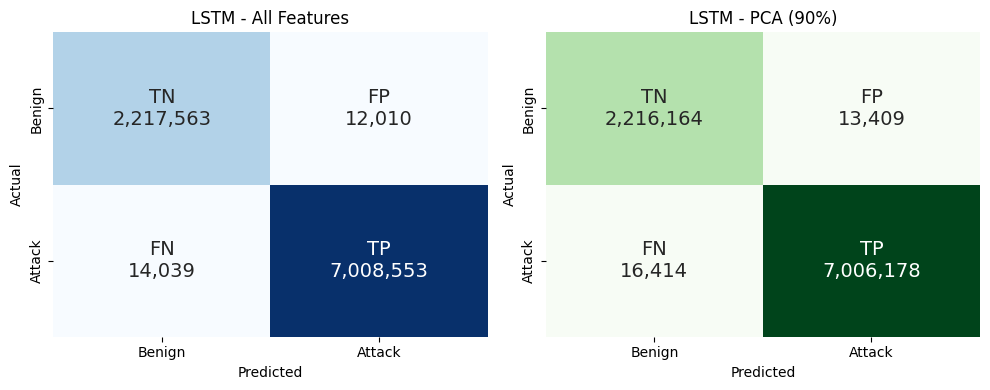

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

cm_full = np.array([
    [2217563,   12010],
    [14039, 7008553]
])

cm_pca = np.array([
    [2216164,   13409],
    [16414, 7006178]
])

plot_cm(cm_full, axes[0], "LSTM - All Features", "Blues")
plot_cm(cm_pca, axes[1], "LSTM - PCA (90%)", "Greens")

plt.tight_layout()
plt.show()

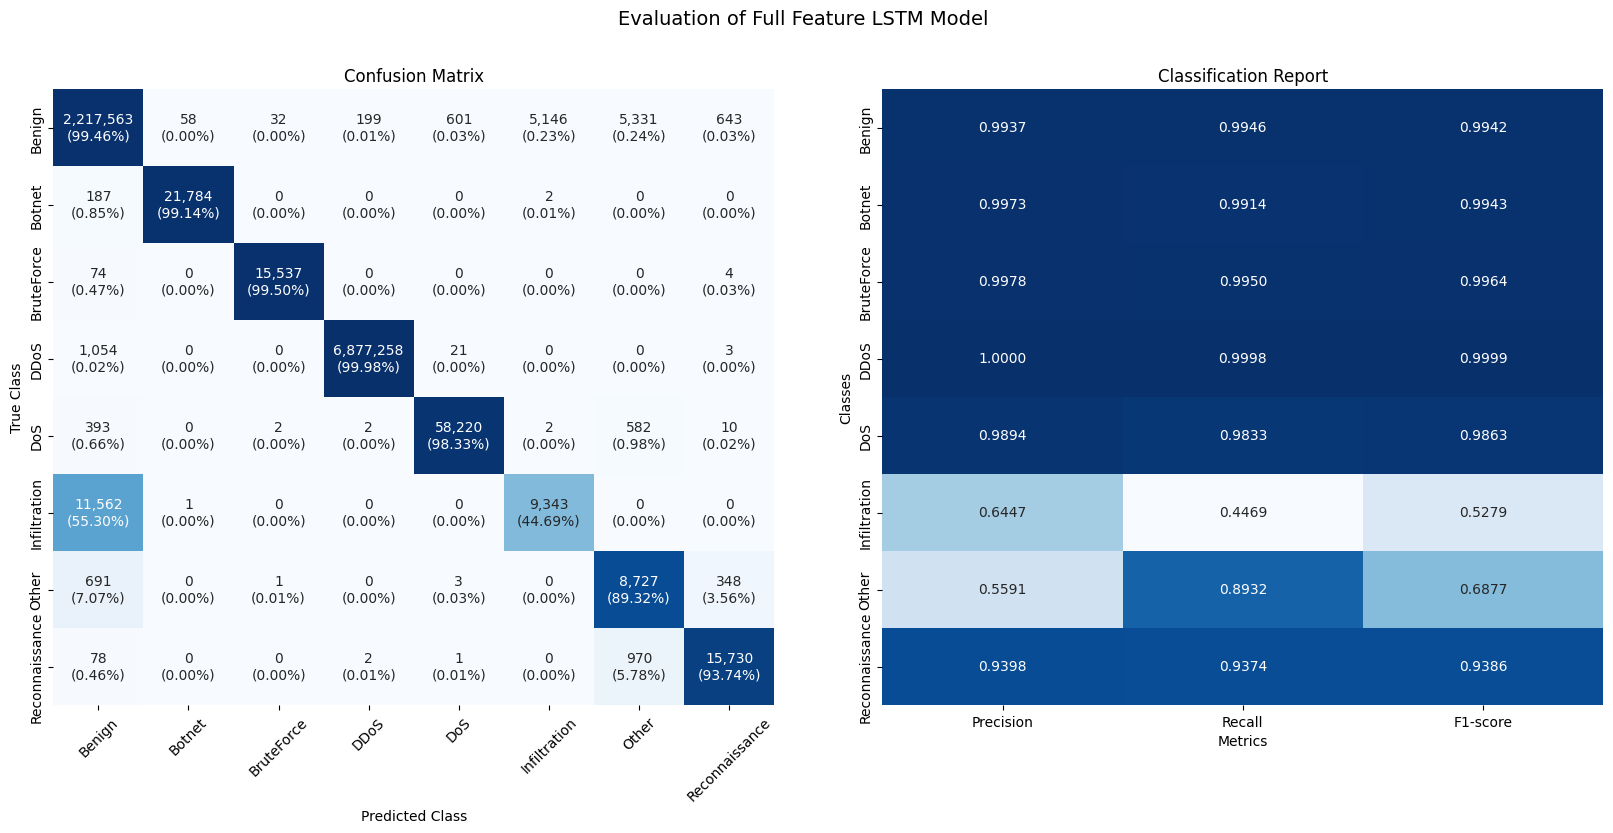

In [19]:
cm_multi = [
    [2217563,      58,      32,     199,     601,    5146,    5331,     643],
    [    187,   21784,      0,       0,       0,       2,       0,       0],
    [     74,       0,   15537,       0,       0,       0,       0,       4],
    [   1054,       0,       0, 6877258,      21,       0,       0,       3],
    [    393,       0,       2,       2,   58220,       2,     582,      10],
    [  11562,       1,       0,       0,       0,    9343,       0,       0],
    [    691,       0,       1,       0,       3,       0,    8727,     348],
    [     78,       0,       0,       2,       1,       0,     970,   15730]
]

labels = [
    "Benign", "Botnet", "BruteForce", "DDoS",
    "DoS", "Infiltration", "Other", "Reconnaissance"
]

precision = [0.9937, 0.9973, 0.9978, 1.0000, 0.9894, 0.6447, 0.5591, 0.9398]
recall    = [0.9946, 0.9914, 0.9950, 0.9998, 0.9833, 0.4469, 0.8932, 0.9374]
f1_score  = [0.9942, 0.9943, 0.9964, 0.9999, 0.9863, 0.5279, 0.6877, 0.9386]

plot_model_evaluation_figure(
    cm=cm_multi,
    class_labels=labels,
    precision=precision,
    recall=recall,
    f1_score=f1_score,
    figure_title="Evaluation of Full Feature LSTM Model"
)

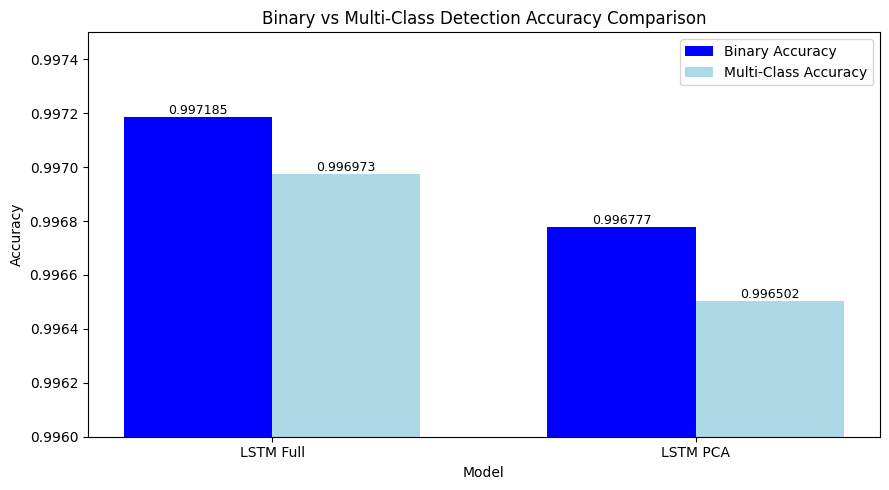

In [ ]:
models = ["LSTM Full", "LSTM PCA"]

binary_acc = [
    0.997185,
    0.996777
]

multiclass_acc = [
    0.996973,
    0.996502
]

plot_accuracy_comparison(models, binary_acc, multiclass_acc)